In [4]:
import sys 
sys.path.append("../../src/")
from common_imports import *
from kibble_zurek import *
#from time_evolved_z_correlators import *
ts = np.logspace(0,3,100)

In [5]:
def scaling_collapse(ts,ns,u=2,v=2):
    #Set L = 512 which works fine
    L = 512
    #Empty Array
    data= np.empty([len(ns),len(ts)])
    #Loop over taus
    for tau_i in tqdm(range(len(ts))):
        #Define Variables
        tau = ts[tau_i]
        t = sqrt(tau)*v
        l = int(sqrt(tau))*u 
        #Define state
        s = state(L,tau,t)
        for n_i in range(len(ns)):
            n = ns[n_i]
            P = P_n(n,s)
            PP = P_n_correlations(n,l,s)
            #Append Correlation
            data[n_i,tau_i]= PP-P*P
    return data

In [6]:
rho=[]
for t in ts:
    s = state(512,(t),sqrt(t)*2)
    rho.append((1/2-sigma_general([0,1],s)/2))
rho = array(rho)

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:44: RuntimeWarning: invalid value encountered in scalar multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:60: RuntimeWarning: invalid value encountered in multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


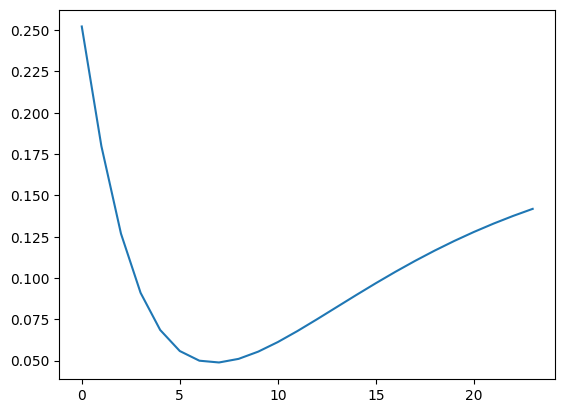

In [44]:
plot(rho)

In [86]:
ns = np.array([1,2,3,4,5,6,7])
ts= np.logspace(0,3,25)
data = scaling_collapse(ts,ns)

  0%|          | 0/25 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
 64%|██████▍   | 16/25 [02:23<02:23, 15.92s/it]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
 96%|█████████▌| 24/25 [11:57<01:36, 96.48s/it]/Users/kristianmunnikhuis/Desktop/subsyst

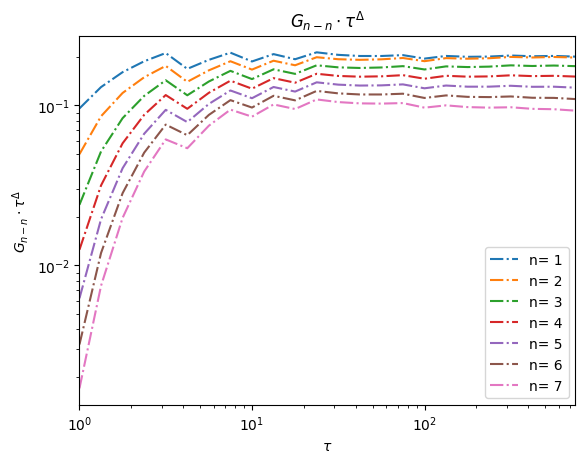

In [94]:
# plot(ns,data[:,::5])
# plt.xlabel(r"$n$")
# plt.ylabel(r"$G_{n-n}$")

# plt.show()
dd = []
for i, d in enumerate(data):
    x = [d[i] for i in range(len(d))]
    n = ns[i]
    plot((ts),array(x)*ts**(1/8),label=f"n= {ns[i]}",ls="dashdot")
    dd.append(x[-2])
#plot(ts,data[0])
plt.title(r"$G_{n-n} \cdot \tau^{\Delta}$")
xlim(ts[0],ts[-2])
xscale("log")
yscale("log")
#ylim(0.05,.25)
xlabel(r"$\tau$")
ylabel(r"$G_{n-n} \cdot \tau^{\Delta}$")
legend()
plt.show()
#plt.plot(ns,dd)
#plt.savefig("Gnn_tau_flatline.pdf")

In [116]:
def scaling_collapse_single(ts,ns,u=1,v=1):
    #Set L = 512 which works fine
    L = 512
    #Empty Array
    data= np.empty([len(ns),len(ts)])
    #Loop over taus
    for tau_i in tqdm(range(len(ts))):
        #Define Variables
        tau = ts[tau_i]
        t = sqrt(tau)*v
        l = int(sqrt(tau))*u 
        #Define state
        s = state(L,tau,t)
        for n_i in range(len(ns)):
            n = ns[n_i]
            P = P_n(n,s)
            #Append Correlation
            data[n_i,tau_i]= P
    return data

In [117]:
x= scaling_collapse_single(ts,ns)

  0%|          | 0/25 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
 96%|█████████▌| 24/25 [00:11<00:01,  1.11s/it]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:44: RuntimeWarning: invalid value encountered in scalar multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:60: RuntimeWarning: invalid value encountered in multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 25/25 [00:15<00:00,  1.6

Text(0.5, 0, '$\\tau$')

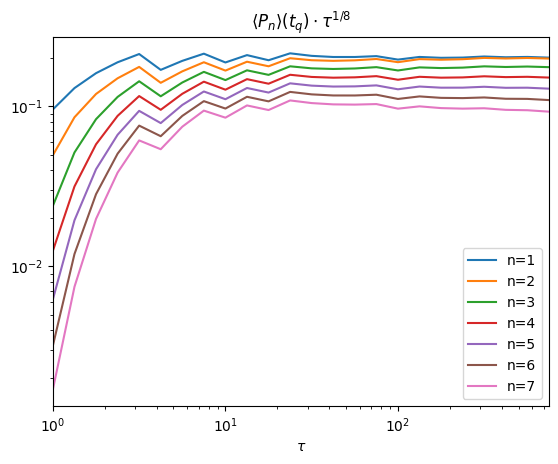

In [120]:
for i, d in enumerate(data):
    n = ns[i]
    plot(ts,d*ts**(1/8),label=f"n={n}")
    #plot(ts,ts**(-1/8)/10)
loglog()
legend()
xlim(ts[0],ts[-2])
title(r"$\langle P_n \rangle (t_q) \cdot \tau^{1/8}$")
xlabel(r"$\tau$")